In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
df = pd.read_csv('placement.csv')
df.shape

(1000, 3)

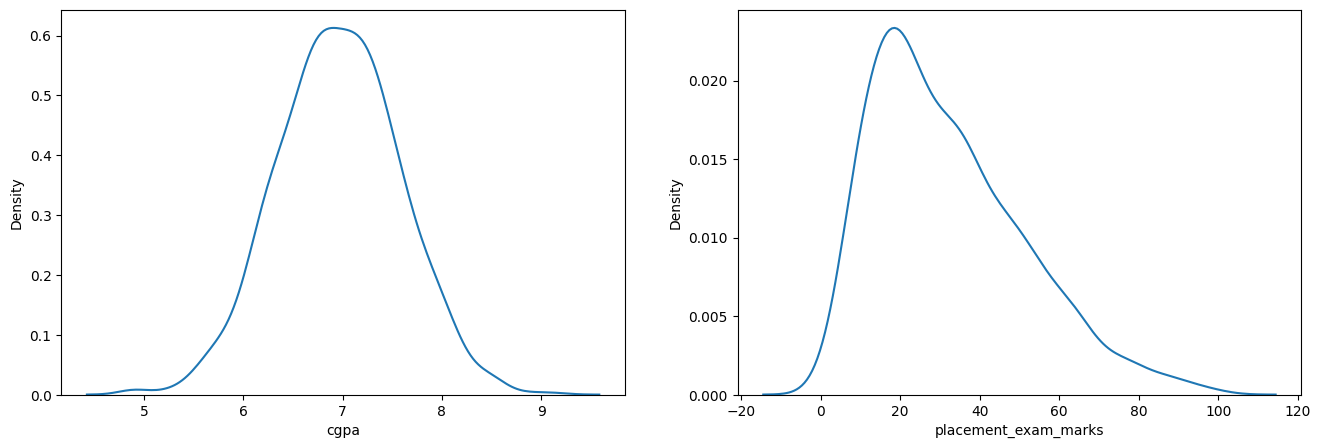

In [126]:
#normal distribution
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])

plt.show()

In [127]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

<Axes: ylabel='placement_exam_marks'>

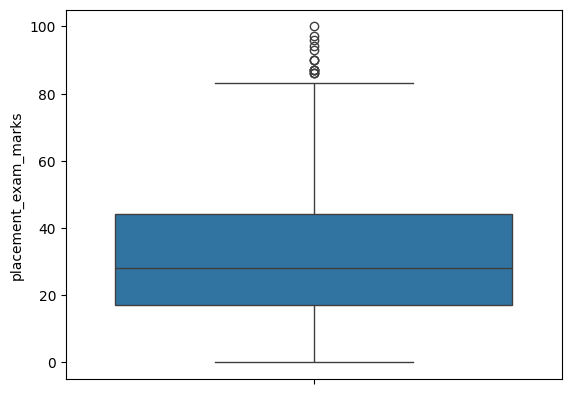

In [128]:
# lets drae the box plot
sns.boxplot(df['placement_exam_marks'])

In [129]:
#now lets remove the outlier
#find the IQR
percetail_25=df['placement_exam_marks'].quantile(0.25)
percetail_75=df['placement_exam_marks'].quantile(0.75)
percetail_25

np.float64(17.0)

In [130]:
Iqr=percetail_75-percetail_25
Iqr

np.float64(27.0)

In [131]:
upper_limit = percetail_75 + 1.5 * Iqr
lower_limit = percetail_25 - 1.5 * Iqr
lower_limit

np.float64(-23.5)

In [132]:
#find the outliers
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [133]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


### Trimming

In [134]:
new_df=df[df['placement_exam_marks']<upper_limit]

<Axes: ylabel='placement_exam_marks'>

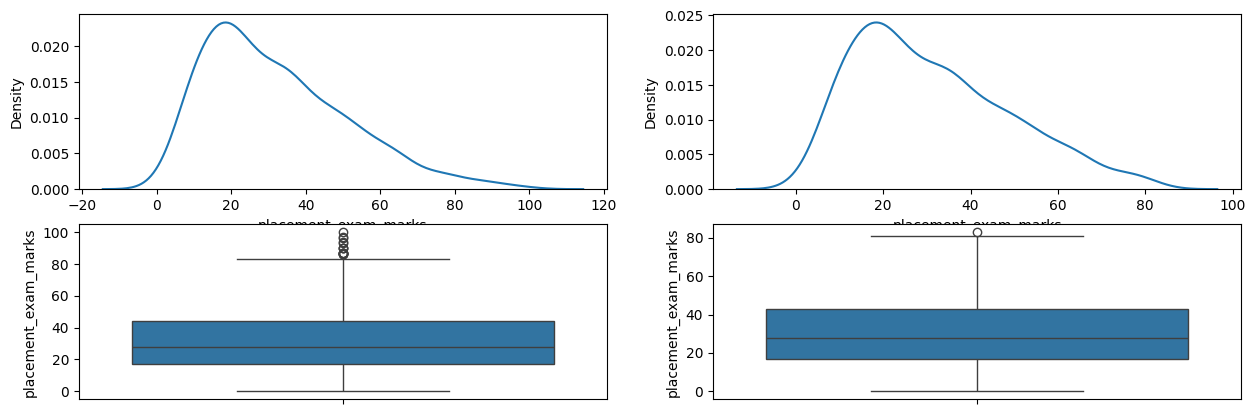

In [135]:
#compare the data
plt.figure(figsize=(15,5))
plt.subplot(2,2,1)
sns.kdeplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.kdeplot(new_df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

#### Capping

In [136]:
new_cap_df = df.copy()

new_cap_df['placement_exam_marks'] = np.where(
    new_cap_df['placement_exam_marks'] > upper_limit,
    upper_limit, 
    np.where(
        new_cap_df['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_cap_df['placement_exam_marks']
    )
)
new_cap_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [137]:
new_cap_df['placement_exam_marks'] = np.where(
    new_cap_df['placement_exam_marks'] > upper_limit, # The actual condition
    upper_limit,                                      # What to do if True
    new_cap_df['placement_exam_marks']                 # What to do if False
)

new_cap_df
new_cap_df.to_csv('output.csv', index=False)

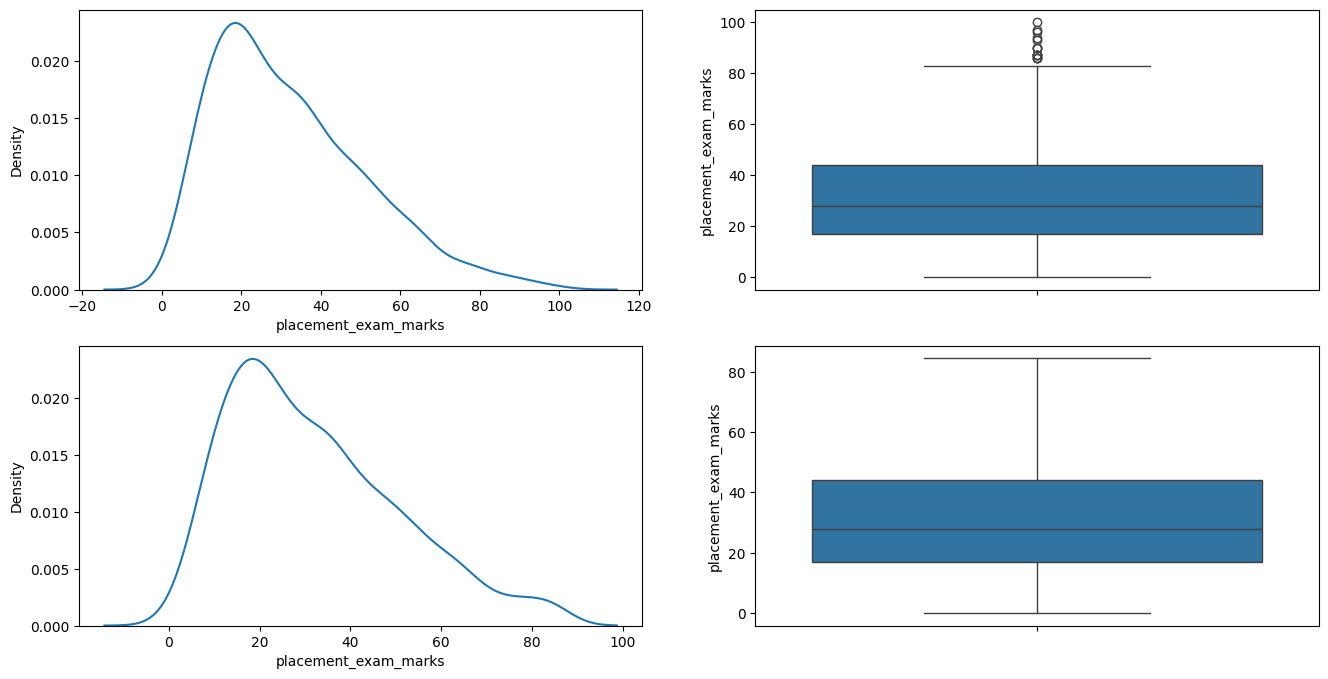

In [138]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.kdeplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.kdeplot(new_cap_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_cap_df['placement_exam_marks'])

plt.show()